# Dzień 3 — Eksploracyjna Analiza Danych (EDA)

Cel: zrozumieć zbiór danych na wylot przed przejściem do embeddingów i RAG.

## 1. Rozkład ocen (`Score`)

Ile recenzji przypada na każdą ocenę (1-5 gwiazdek)? Czy dane są zbalansowane?

<Axes: xlabel='Score'>

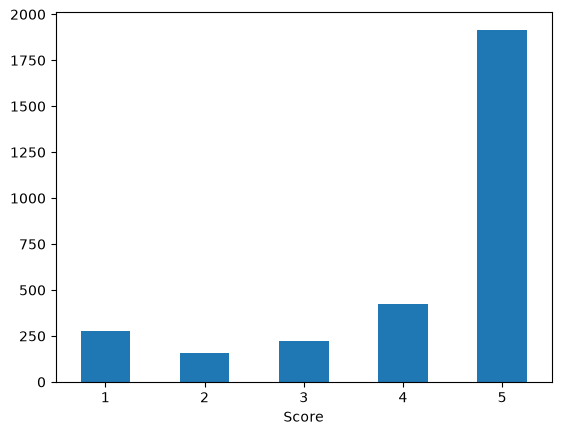

In [13]:
import pandas as pd

df = pd.read_csv("../data/processed/reviews_clean.csv")
df = df.groupby(['Score']).size()
df.plot(kind="bar", rot=0)

Najwięcej recenzji mają dania ocenione >4/5 (ponad 2500) z tego powodu dominować będą oceny pozytywne. Najwięcej ocen negatywnych ma wynik 1/5 (ponad 250), mimo to jest to wynik około 10 razy mniejszy niż w przypadku recenzji poztywnych.

## 2. Długość recenzji vs ocena

Hipoteza: czy złe recenzje (1-2 gwiazdki) są dłuższe czy krótsze niż dobre?

<Axes: xlabel='Score'>

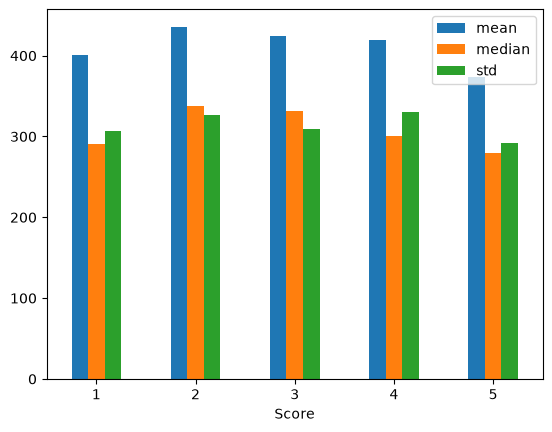

In [ ]:
import pandas as pd

df = pd.read_csv("../data/processed/reviews_clean.csv")
score = pd.DataFrame()
score["mean"] = df.groupby(['Score'])['text_length'].mean()
score['median'] = df.groupby(['Score'])['text_length'].median()
score['std'] = df.groupby(['Score'])['text_length'].std()
score.plot(kind="bar", rot=0)

Statystyki długości tekstu są do siebie bardzo zbliżone w każdym wariancie oceny. Średnia długość tekstu dań ocenionych 5/5 jest jednak wyraźnie niższa od pozostałych, jest to jednak różnica 30 znaków, czyli bardzo niewielka. Średnie długości recenzji mają się w przedziale od ~370 do ~420, mediana od ~290 do ~320 i odchylenie od ~300 do ~320.

## 3. Analiza tekstowa — najczęstsze słowa/frazy

Porównaj najczęstsze słowa w recenzjach 1-gwiazdkowych vs 5-gwiazdkowych (lowercase + stopwords TYLKO tutaj, do wizualizacji — nie modyfikuj oryginalnej kolumny `Text`). 

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def get_most_common_words(df, score):
    texts = df.loc[df["Score"] == score, "Text"]
    matrix = vectorizer.fit_transform(texts)
    words = vectorizer.get_feature_names_out()
    counts = matrix.sum(axis=0)
    frequency = counts / counts.sum() * 10000
    word_counts = pd.DataFrame({"word": words, "count": counts.flat, "frequency": frequency.flat})
    word_counts = word_counts.sort_values(by="frequency", ascending=False)
    return word_counts

df = pd.read_csv("../data/processed/reviews_clean.csv")
negations = {"no", "not", "nor", "never", "none", "nobody", "nothing", "neither", "nowhere", "cannot"}
stop_words = sorted(ENGLISH_STOP_WORDS - negations)

vectorizer = CountVectorizer(stop_words=stop_words, lowercase=True, token_pattern=r'\b\w+\b')

print(get_most_common_words(df, 1).head(10))
print(get_most_common_words(df, 5).head(10))

         word  count   frequency
1737      not    217  217.543860
2619        t    142  142.355890
1494     like    134  134.335840
2006  product    116  116.290727
2638    taste     95   95.238095
2236        s     92   92.230576
540    coffee     85   85.213033
1413     just     70   70.175439
1723       no     67   67.167920
1160     good     64   64.160401
         word  count   frequency
6156        s    896  137.742317
7228        t    835  128.364771
4844      not    805  123.752863
4131     like    676  103.921659
3194    great    651  100.078402
3113     good    595   91.469508
7289    taste    516   79.324817
3872     just    503   77.326323
4238     love    492   75.635290
5579  product    465   71.484573


Najczestsze pojawiajace sie slowa dla ocen 1 gwiazdkowych to: not, like, product, taste czy coffee. Najczesciej pojawiajace sie slowa recenzji 5 gwiazdkowych to: not, like, great, good, taste, love. W obu wynikach pojawily sie "slowa" takie jak "s" i "t" co jest powodowane przez dzielenie regexem slow takich jak it's, czy don't, gdzie apostrof znika przez co owa fraza jest rozbijana na 2 oddzielne slowa.

## 4. Analiza czasowa

Jak liczba recenzji i średnia ocena zmieniają się w czasie (agregacja po miesiącu/roku)? Zwizualizuj jako wykres liniowy.

array([<Axes: xlabel='Year,Month'>, <Axes: xlabel='Year,Month'>],
      dtype=object)

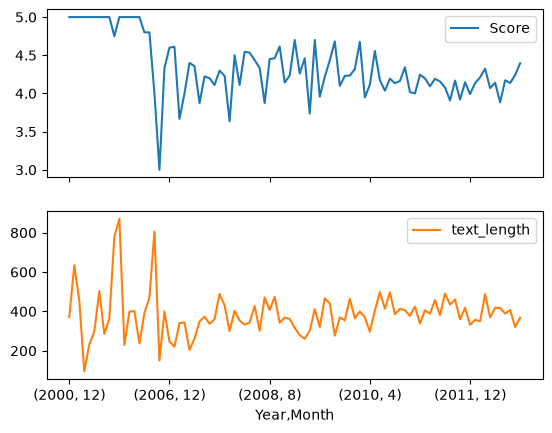

In [ ]:
import pandas as pd

df = pd.read_csv("../data/processed/reviews_clean.csv")
df['date'] = pd.to_datetime(df['date'])
df['Year'] = df['date'].dt.year
df['Month'] = df['date'].dt.month
df.groupby(['Year', 'Month']).agg({'Score': 'mean', 'text_length': 'mean'}).plot(kind='line', subplots=True)

Od 2000 do około połowy 2006 roku oceny dań miały tendencję liniową i w kazdym miesiacu ich srednia wynosila 5.0, jednak wraz z nagłym zmniejszeniem się długości recenzji średnia ocen wahała się z miesiąca na miesiąc między 4.0, a 4.5. Czynnikiem tak naglego spadku moze byc popularyzacja strony i internetu, co trzeba by bylo sprawdzic iloscia recenzji wystawianych w miesiacu.

## 5. Analiza per produkt

Które produkty mają najwięcej recenzji?

In [ ]:
import pandas as pd

df = pd.read_csv("../data/processed/reviews_clean.csv")
print(df.groupby('ProductId').size().sort_values(ascending=False).head(10))

ProductId
B003B3OOPA    9
B0013NUGDE    8
B004ZIER34    6
B002IEZJMA    6
B002QWP89S    6
B004E4CCSQ    6
B001L4JH5I    6
B005K4Q37A    6
B008J1HO4C    5
B0018KR8V0    5
dtype: int64


Produkty o ID: B003B3OOPA i B0013NUGDE mają najwięcej recenzji, odpowiednio 9 i 8. Następne wyniki największej ilości recenzji to <=6, co uwydatnia popularność dwóch wczesniej wymienionych produktów.

## 6. Sprawdzenie jakości próbki

Porównaj rozkład ocen w próbce (2000-5000 recenzji) z rozkładem w całym zbiorze — sprawdź, czy stratyfikowane próbkowanie zachowało proporcje.

<Axes: xlabel='Score'>

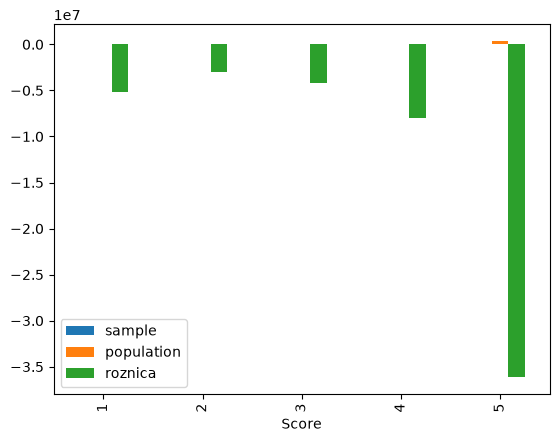

In [ ]:
import pandas as pd

sample = pd.read_csv("../data/processed/reviews_clean.csv", usecols=['Score'])
population = pd.read_csv("../data/raw/Reviews.csv", usecols=['Score'])

sample_distribution = sample['Score'].value_counts().sort_index()
population_distribution = population['Score'].value_counts().sort_index()

comparison = pd.DataFrame({'sample': sample_distribution, 'population': population_distribution})
comparison['roznica'] = (comparison['sample'] - comparison['population']) * 100
comparison['roznica'].plot(kind='bar')

## Podsumowanie

_TODO: 4-5 najważniejszych wniosków z EDA (do wykorzystania później w README/CV)._

1. ...
2. ...
3. ...
4. ...
5. ...